In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume (1).csv


In [7]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [8]:
df['holiday'] = df['holiday'].fillna(0)
df['holiday'] = df['holiday'].apply(lambda x: 1 if x != 0 else 0)

In [9]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['weekend'] = (df['day_of_week'] >= 5).astype(int)

In [10]:
df = df.drop(columns=['date_time', 'weather_description'])

In [11]:
df = pd.get_dummies(
    df,
    columns=['weather_main'],
    drop_first=True,
    dtype=int
)

In [12]:
scaler = MinMaxScaler()

continuous_features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'day_of_week',
    'month'
]

df[continuous_features] = scaler.fit_transform(df[continuous_features])

In [13]:
SEQ_LEN = 24
TARGET = 'traffic_volume'

In [14]:
features = df.drop(columns=[TARGET]).values
target = df[TARGET].values

In [15]:
X = []
y = []

for i in range(SEQ_LEN, len(df)):
    X.append(features[i-SEQ_LEN:i])
    y.append(target[i])

X = np.array(X)
y = np.array(y)

In [16]:
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

In [17]:
print(X.shape)
print(y_scaled.shape)

(48180, 24, 19)
(48180, 1)


In [18]:
train_size = int(0.8 * len(X))

X_train = X[:train_size]
y_train = y_scaled[:train_size]

X_test = X[train_size:]
y_test = y_scaled[train_size:]

In [19]:
print(X_train.shape)
print(X_test.shape)

(38544, 24, 19)
(9636, 24, 19)


In [20]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        32,
        activation='tanh',
        input_shape=(SEQ_LEN, X.shape[2])
    )
)

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer=Adam(0.001),
    loss='mse'
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697 (6.63 KB)

 Trainable params: 1,697 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [22]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0347 - val_loss: 0.0162
Epoch 2/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0195 - val_loss: 0.0168
Epoch 3/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0174 - val_loss: 0.0119
Epoch 4/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0161 - val_loss: 0.0123
Epoch 5/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0151 - val_loss: 0.0109
Epoch 6/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0144 - val_loss: 0.0110
Epoch 7/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0139 - val_loss: 0.0100
Epoch 8/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0133 - val_loss: 0.0097
Epoch 9/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0127 - val_loss: 0.0095
Epoch 10/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0123 - val_loss: 0.0085
Epoch 11/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0120 - val_loss: 0.0095
Epoch 12/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/ste

In [23]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        activation='tanh',
        input_shape=(SEQ_LEN, X.shape[2])
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer=Adam(0.001),
    loss='mse'
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0328 - val_loss: 0.0181
Epoch 2/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0190 - val_loss: 0.0133
Epoch 3/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0156 - val_loss: 0.0150
Epoch 4/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0137 - val_loss: 0.0125
Epoch 5/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 0.0124 - val_loss: 0.0101


In [25]:
y_pred_rnn_scaled = rnn_model.predict(X_test)
y_pred_rnn = y_scaler.inverse_transform(y_pred_rnn_scaled)

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [26]:
y_pred_lstm_scaled = lstm_model.predict(X_test)
y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm_scaled)

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [27]:
y_test_original = y_scaler.inverse_transform(y_test)

In [28]:
rmse_rnn = np.sqrt(mean_squared_error(y_test_original, y_pred_rnn))
rmse_lstm = np.sqrt(mean_squared_error(y_test_original, y_pred_lstm))

mae_rnn = mean_absolute_error(y_test_original, y_pred_rnn)
mae_lstm = mean_absolute_error(y_test_original, y_pred_lstm)

In [29]:
print("RNN RMSE:", rmse_rnn)
print("LSTM RMSE:", rmse_lstm)

print("RNN MAE:", mae_rnn)
print("LSTM MAE:", mae_lstm)

RNN RMSE: 660.6720877674538
LSTM RMSE: 962.8426779203091
RNN MAE: 472.9388564891368
LSTM MAE: 742.170293868952


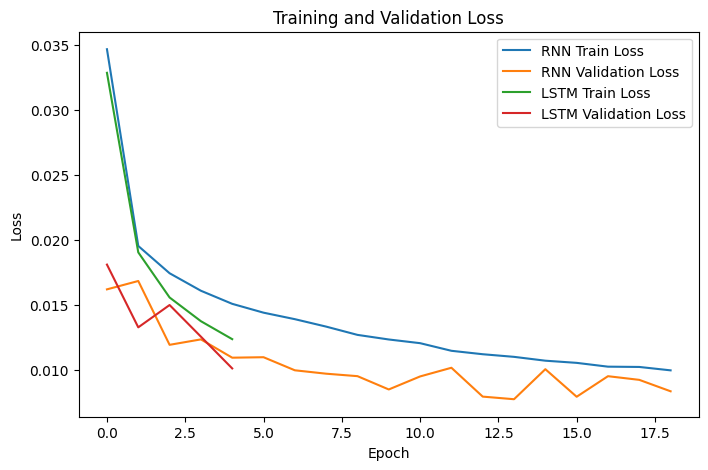

In [30]:
plt.figure(figsize=(8,5))

plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Validation Loss')

plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

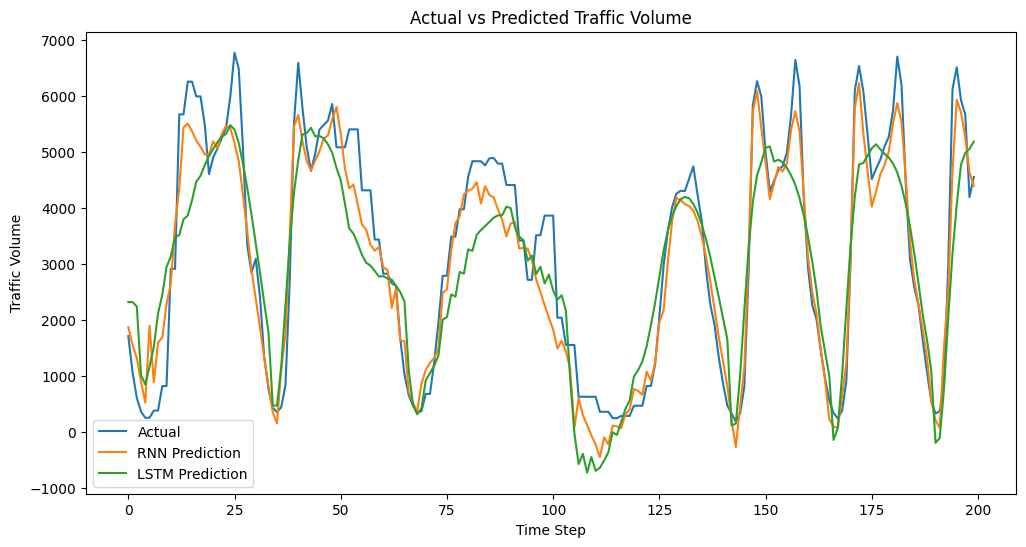

In [31]:
plt.figure(figsize=(12,6))

plt.plot(y_test_original[:200], label='Actual')
plt.plot(y_pred_rnn[:200], label='RNN Prediction')
plt.plot(y_pred_lstm[:200], label='LSTM Prediction')

plt.xlabel('Time Step')
plt.ylabel('Traffic Volume')
plt.title('Actual vs Predicted Traffic Volume')
plt.legend()
plt.show()

1. Why do we need sequences in RNN/LSTM?
RNN and LSTM are designed for sequential data. They use previous time steps to predict future values.

2. Main limitation of RNN
RNN suffers from vanishing gradient problem, making it difficult to learn long-term dependencies.

3. How LSTM solves this problem
LSTM uses memory cells and gates to retain important information over longer sequences.

4. Which model performed better and why
LSTM performed better because it can remember long-term dependencies and handle sequential patterns more effectively than simple RNN.

In [32]:
from tensorflow.keras.layers import GRU

In [33]:
gru_model = Sequential()

gru_model.add(
    GRU(
        64,
        activation='tanh',
        input_shape=(SEQ_LEN, X.shape[2])
    )
)

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
